In [88]:
from multiprocessing import Process, Queue

def worker(rank, size, task_queue, result_queue):
    while True:
        task = task_queue.get()
        if task is None:  # Sentinel value to indicate no more tasks
            break
        # Perform some computation based on the task
        result = f"Process {rank} processed task {task}"
        result_queue.put(result)


num_processes = 1  # Number of processes (similar to MPI size)
task_queue = Queue()
result_queue = Queue()

# Create and start processes
processes = []
for rank in range(num_processes):
    p = Process(target=worker, args=(rank, num_processes, task_queue, result_queue))
    p.start()
    processes.append(p)

# Add tasks to the queue
for i in range(10):  # Example: 10 tasks
    task_queue.put(i)

# Add sentinel values to signal the end of tasks
for _ in range(num_processes):
    task_queue.put(None)

# Collect results
for _ in range(10):  # Example: 10 results expected
    result = result_queue.get()
    print(result)

# Join processes
for p in processes:
    p.join()

Process 0 processed task 0
Process 0 processed task 1
Process 0 processed task 2
Process 0 processed task 3
Process 0 processed task 4
Process 0 processed task 5
Process 0 processed task 6
Process 0 processed task 7
Process 0 processed task 8
Process 0 processed task 9


In [89]:
rank = rank#comm.Get_rank()
size = num_processes#comm.Get_size()

1. sma:1981-2020

In [61]:
import numpy as np
import xarray as xr
def calculate_percentile(x, y):
    count = np.sum(y <= x)
    total = len(y)
    percentile = (count / total) * 100
    return percentile

def replace_values(sma_40,lat,lon):
    nearest_point = sma_40.sel(latitude=lat, longitude=lon, method='nearest')
    nearest_lat = nearest_point['latitude'].values
    nearest_lon = nearest_point['longitude'].values
    lat_index = np.abs(sma_40['latitude'].values - nearest_lat).argmin()
    lon_index = np.abs(sma_40['longitude'].values - nearest_lon).argmin()
    return lat_index,lon_index

sma_era5=xr.open_dataarray("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/sma_1981_2020.nc")
y=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:,:,-1]
nanindex=np.where(np.isnan(y[:,205]))
y=np.delete(y,nanindex,axis=0)
lats=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats.npy")
lons=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons.npy")
lats=np.delete(lats,nanindex,axis=0)
lons=np.delete(lons,nanindex,axis=0)
sma_esa_era=sma_era5.values
for i in range(733):
    new_value=y[i,:]
    lati=lats[i]
    loni=lons[i]
    lat_index,lon_index=replace_values(sma_era5,lati,loni)
    sma_esa_era[240:480-24,lat_index,lon_index]=new_value

sma_esa_era= xr.Dataset({"sma": (["time","latitude", "longitude"], sma_esa_era)},
    coords={"time": sma_era5.time,"lat": sma_era5.latitude, "lon":sma_era5.longitude})
sma_esa_era.to_netcdf('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/sma.nc')


#2.calculate percentage

In [67]:
import numpy as np
from netCDF4 import Dataset
from datetime import datetime
from dateutil.relativedelta import relativedelta
import drought.drought_clusters_utils as dclib
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

dataset = "."
start_date = datetime(2001, 1, 1)
percentiles_path = "/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/percentiles.nc"
f = Dataset('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/sma.nc')
sma = f.variables['sma'][:]
lons = f.variables["longitude"][:]
lats = f.variables["latitude"][:]
f.close()
print("hfn okk")

##################################################################################
############################# CARRY OUT CALCULATIONS #############################
##################################################################################

anomalies = sma  
new_start_date = start_date + relativedelta(years=1)
seasonality_bool = False
percentiles_matrix = dclib.calculate_percentiles_matrix(anomalies, seasonality_bool)
units = "percentiles"
var_name_percentiles = "percentiles"
var_info = "Percentiles of SM cumulative anomalies from " + dataset + "."
print("hfn okk2")

# Save percentiles matrix
dclib.save_netcdf_file(percentiles_matrix,lons,lats,units,var_name_percentiles,var_info,percentiles_path,new_start_date,)
print("Done calculating and saving percentiles.")


hfn okk
hfn okk2
Done calculating and saving percentiles.


In [ ]:
===============================================
3.找干旱事件

In [90]:
import yaml
import numpy as np
import pickle
from netCDF4 import Dataset
from datetime import datetime
from dateutil.relativedelta import relativedelta
import drought.drought_clusters_utils as dclib
import os
rank = rank#comm.Get_rank()
size = num_processes#comm.Get_size()

##################################################################################
############################ SET PATHS AND DEFINITIONS ###########################
##################################################################################

# Load all the definitions needed to run this file
with open("/User/homes/fhuang/lac_cnn/drought/definitions.yaml") as f:
    definitions = yaml.load(f, Loader=yaml.FullLoader)

# Name of the dataset used to calculate gridded drought metric
dataset = ''

# Region where this analysis is carried out
region = 'Global'

# Name of the drought metric
drought_metric = 'SMA_percentiles'

# Threshold for drought definition
drought_threshold = 0.1
drought_threshold_name = str(0.1)

# Start and end years for the timer period for which we will identify the drought clusters
start_year = 1981
end_year = 2020

# Set boolean variable of whether to treat the right/left edges of the map as periodic
periodic_bool = True

# Path and file name of the NetCDF file with the drought metric
drought_metric_path = "/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/"
drought_metric_file_name = 'percentiles.nc'

# Names of the variables in the NetCDF file with the drought metric
lat_var = 'lat'
lon_var = 'lon'
metric_var = 'percentiles'

# Path where the drought clusters will be saved
clusters_partial_path = '/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era'
clusters_full_path = (clusters_partial_path+ "/"+ region+ "/"+ drought_metric+ "/" + drought_threshold_name + "/")

# Threshold for minimum cluster area (km^2)
minimum_area_threshold = 0


if not os.path.exists(clusters_full_path):  
    os.makedirs(clusters_full_path)
######################## DONE SETTING PATHS AND DEFINTIONS #######################

# Load the 3D array with the drought metric (t, lat, lon)
f = Dataset(drought_metric_path + drought_metric_file_name)
drought_metric = f.variables[metric_var][:]
lons = f.variables[lon_var][:]
lats = f.variables[lat_var][:]
f.close()

# Set date time objects and the number of time steps
start_date = datetime(start_year, 1, 1)
nsteps = (end_year - start_year + 1) * 12
date_temp = start_date

# Spatial resolution of dataset in each direction
resolution_lon = np.mean(lons[1:] - lons[:-1])
resolution_lat = np.mean(lats[1:] - lats[:-1])

##################################################################################
#################### IDENTIFY DROUGHT CLUSTERS (PER TIME STEP) ###################
##################################################################################

# Function to carry out analysis in parallel. Each core is given a chunk of the time steps to analyze.
def find_clusters(chunk):

    # Length of the chunk
    chunk_length = len(chunk)

    # Repeat analysis for each time step within the assigned chunck
    for i in range(0, chunk_length):

        # Current date
        current_date = start_date + relativedelta(months=int(chunk[i]))

        # STEP 1: GET DATA FOR THE CURRENT TIME STEP
        current_data_slice = drought_metric[int(chunk[i]), :, :]

        # STEP 2: APPLY MEDIAN FILTER TO THE TIME STEP IN EACH FIELD TO SMOOTH OUT NOISE
        filtered_slice = dclib.median_filter(current_data_slice)

        # STEP 3: APPLY DROUGHT THRESHOLD DEFINITION (e.g. 20th percentile)
        droughts = dclib.filter_non_droughts(filtered_slice, drought_threshold)

        # STEP 4: IDENTIFY DROUGHT CLUSTERS PER TIME STEP
        print(str(rank + 1)
            + ": Identifying clusters for time step "
            + str(int(chunk[i]) + 1)
            + " of "
            + str(nsteps)
            + " ("
            + str(i + 1)
            + "/"
            + str(chunk_length)
            + ")..."
        )
        cluster_count, cluster_dictionary = dclib.find_drought_clusters(
            droughts, lons, lats, resolution_lon, resolution_lat, periodic_bool
        )
        #########################################这里不要step5，容易出错，后面再将小干旱过滤#########################
        # # STEP 5: FILTER DROUGHT CLUSTERS BY AREA AND IF THE CENTROID LIES IN THE SAHARA
        # droughts, cluster_count, cluster_dictionary = dclib.filter_drought_clusters(
        #     droughts, cluster_count, cluster_dictionary, minimum_area_threshold
        # )

        # STEP 6: SAVE THE DROUGHT CLUSTERS FOR CURRENT TIME STEP

        # Paths and file names for saving data
        f_name_slice = (
            clusters_full_path + "cluster-matrix_" + str(current_date) + ".pck"
        )
        f_name_dictionary = (
            clusters_full_path + "cluster-dictionary_" + str(current_date) + ".pck"
        )
        f_name_count = (
            clusters_full_path + "cluster-count_" + str(current_date) + ".pck"
        )

        # Save the data in pickle format
        with open(f_name_slice, "wb") as f:
            pickle.dump(droughts,f,pickle.HIGHEST_PROTOCOL)
        with open(f_name_dictionary, "wb") as f:
            pickle.dump(cluster_dictionary, f,pickle.HIGHEST_PROTOCOL)
            
        with open(f_name_count, "wb") as f:
            pickle.dump(cluster_count, f, pickle.HIGHEST_PROTOCOL)
            
        print(
            "Rank "
            + str(rank + 1)
            + ": Saved data for time step "
            + str(int(chunk[i]) + 1)
            + " of "
            + str(nsteps)
            + " ("
            + str(i + 1)
            + "/"
            + str(chunk_length)
            + ")."
        )

    return


# Number of steps for each processor
offset = 0
h = np.ceil(nsteps / np.float32(size - offset))

# Number of steps that each process will be required to do
if rank >= offset and rank < size - 1:
    chunk = np.arange((rank - offset) * h, (rank - offset) * h + h)
elif rank == size - 1:
    chunk = np.arange((rank - offset) * h, nsteps)

# Identify drought clusters for the current chunk of data
find_clusters(chunk)


1: Identifying clusters for time step 1 of 480 (1/480)...
Rank 1: Saved data for time step 1 of 480 (1/480).
1: Identifying clusters for time step 2 of 480 (2/480)...
Rank 1: Saved data for time step 2 of 480 (2/480).
1: Identifying clusters for time step 3 of 480 (3/480)...
Rank 1: Saved data for time step 3 of 480 (3/480).
1: Identifying clusters for time step 4 of 480 (4/480)...
Rank 1: Saved data for time step 4 of 480 (4/480).
1: Identifying clusters for time step 5 of 480 (5/480)...
Rank 1: Saved data for time step 5 of 480 (5/480).
1: Identifying clusters for time step 6 of 480 (6/480)...
Rank 1: Saved data for time step 6 of 480 (6/480).
1: Identifying clusters for time step 7 of 480 (7/480)...
Rank 1: Saved data for time step 7 of 480 (7/480).
1: Identifying clusters for time step 8 of 480 (8/480)...
Rank 1: Saved data for time step 8 of 480 (8/480).
1: Identifying clusters for time step 9 of 480 (9/480)...
Rank 1: Saved data for time step 9 of 480 (9/480).
1: Identifying clus

In [ ]:
===============================================
4.追踪干旱事件并合并

In [92]:
import yaml
import numpy as np
import pickle
from netCDF4 import Dataset
from datetime import datetime
from dateutil.relativedelta import relativedelta
import drought.drought_clusters_utils as dclib
# Start and end date and number of time steps in between
start_year = 1981
end_year = 2020
start_date = datetime(start_year, 1, 1)
nt = (end_year - start_year +1) * 12
end_date = start_date + relativedelta(months=nt - 1)

# Load coordinates
f = Dataset(drought_metric_path + drought_metric_file_name)
lons = f.variables[lon_var][:]
lats = f.variables[lat_var][:]
f.close()

# Track drought clusters through time (Note: only need to run once after calculating drought clusters)
dclib.track_clusters_and_save(clusters_full_path,start_date,end_date,nt,lons,lats,drought_threshold_name,dataset,)
print("Done tracking drought clusters.")


1981-02-01 00:00:00 [Appear]: Cluster 64 appeared.
1981-02-01 00:00:00 [Appear]: Cluster 71 appeared.
1981-02-01 00:00:00 [Appear]: Cluster 75 appeared.
1981-02-01 00:00:00 [Appear]: Cluster 78 appeared.
1981-02-01 00:00:00 [Appear]: Cluster 81 appeared.
1981-02-01 00:00:00 [Appear]: Cluster 83 appeared.
1981-02-01 00:00:00 [Appear]: Cluster 97 appeared.
1981-02-01 00:00:00 [Disappear]: Cluster 1 disappeared or merged.
1981-02-01 00:00:00 [Disappear]: Cluster 2 disappeared or merged.
1981-02-01 00:00:00 [Disappear]: Cluster 3 disappeared or merged.
1981-02-01 00:00:00 [Disappear]: Cluster 4 disappeared or merged.
1981-02-01 00:00:00 [Disappear]: Cluster 5 disappeared or merged.
1981-02-01 00:00:00 [Disappear]: Cluster 6 disappeared or merged.
1981-02-01 00:00:00 [Disappear]: Cluster 7 disappeared or merged.
1981-02-01 00:00:00 [Disappear]: Cluster 8 disappeared or merged.
1981-02-01 00:00:00 [Disappear]: Cluster 9 disappeared or merged.
1981-02-01 00:00:00 [Disappear]: Cluster 10 disap

In [ ]:
===============================================
5.整理成格点序列形式

In [111]:
import pandas as pd
import pickle
import datetime

# 打开并加载数据
with open("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/Global/SMA_percentiles/0.1/tracked_clusters_dictionary_1981-2020.pck", 'rb') as file:
    data = pickle.load(file)

k=0
m=0
drought_new_index=np.full((107,240,217),np.nan)
drought_new_info=pd.DataFrame()
time00=datetime.datetime(2001, 1, 1, 0, 0)
for i in range(1,len(data)):
    try:
        for year in range(2001,2019):
            for month in range(1,13):
                time0=datetime.datetime(year, month, 1, 0, 0)
                
                if time0==data[i]['start']:
                    datai=data[i]
                    centroid_lat=datai.get(time0)['centroid'][0]
                    centroid_lon=datai.get(time0)['centroid'][1]
                    area=datai.get(time0)['area']
            
                    if (-82<centroid_lat <-35)and (-60<centroid_lon<20):#and(abs(area)>22500)
                        coordinates=datai.get(time0)['coordinates']
                        drought_new_info.loc[k,"index"]=k
                        drought_new_info.loc[k,"time"]=m
                        drought_new_info.loc[k,"old_index"]=i
                        drought_new_info.loc[k,'centroid_lat']=centroid_lat
                        drought_new_info.loc[k,'centroid_lon']=centroid_lon
                        drought_new_info.loc[k,'area']=area
                        drought_new_info.loc[k,'intensity']=datai.get(time0)['intensity']
                        k=k+1
                        for coordinate in coordinates:
                            drought_new_index[coordinate[0],coordinate[1],m]=i
                        parent_ofs=datai['parent_of']
                        
                        for p in parent_ofs:
                            datai=data[p]
                            start_time=datai['start']
                            centroid_lat=datai.get(start_time)['centroid'][0]
                            centroid_lon=datai.get(start_time)['centroid'][1]
                            area=datai.get(start_time)['area']
                
                            year_diff = start_time.year - time00.year
                            month_diff = start_time.month - time00.month
                            m=year_diff * 12 + month_diff
                            if (-82<centroid_lat <-35)and (-60<centroid_lon<20):#and(abs(area)>225000)
                                coordinates=datai.get(start_time)['coordinates']
                                drought_new_info.loc[k,"index"]=k
                                drought_new_info.loc[k,"parent_index"]=i
                                drought_new_info.loc[k,"time"]=m
                                drought_new_info.loc[k,"old_index"]=p
                                drought_new_info.loc[k,'centroid_lat']=centroid_lat
                                drought_new_info.loc[k,'centroid_lon']=centroid_lon
                                drought_new_info.loc[k,'area']=area
                                drought_new_info.loc[k,'intensity']=datai.get(start_time)['intensity']
                                k=k+1
                                for coordinate in coordinates:
                                    print(i,p,m)
                                    drought_new_index[coordinate[0],coordinate[1],m]=p
                 
                
    except:
        pass
    continue
np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_index.npy",drought_new_index)
drought_new_info.to_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_info.csv")

10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10848 10891 1
10889 10926 2
10889 10926 2
10889 10926 2
10889 10926 2
10889 10926 2
10889 10926 2
10889 10926 2
10914 10967 3
10914 10967 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 10986 3
10925 

In [115]:
drought_clusters=xr.open_dataarray("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/Global/SMA_percentiles/0.1/drought_clusters__0.1_1981-2020.nc",
                    decode_times=False)
drought_new_index_xr = xr.DataArray(drought_new_index[:,:,:-1], 
                       coords={'lat': drought_clusters.lat,'lon': drought_clusters.lon,'time': pd.date_range("2001-01-01", freq="ME", periods=216)}, 
                       dims=["lat", "lon", "time"])
drought_new_index_xr.to_netcdf("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_index.nc")

In [30]:
from get_lat_lon import get_lat_lon
import xarray as xr
sa_xcell=np.load("/User/homes/fhuang/lac_cnn/sa_x_cell.npy")
nan_idx=np.load('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/conv3d_res/nan_idx.npy')
sa_xcell=np.delete(sa_xcell,nan_idx,axis=0)
y=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:,:,-1]
nanindex=np.where(np.isnan(y[:,205]))
y=np.delete(y,nanindex,axis=0)
lats=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats.npy")
lons=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons.npy")
lats=np.delete(lats,nanindex,axis=0)
lons=np.delete(lons,nanindex,axis=0)
sa_xcell=np.delete(sa_xcell,nanindex,axis=0)
drought_new_index_xr=xr.open_dataarray("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_index.nc")
drought_new_index_np=np.full((733,216),np.nan)
for i in range(733):
    lati,loni=get_lat_lon(sa_xcell[i])
    drought_new_index_np[i,:]=drought_new_index_xr.sel(lat=lati,lon=loni, method='nearest').values
np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_index_np_all.npy",drought_new_index_np)

In [169]:
from get_lat_lon import get_lat_lon
smap=xr.open_dataarray("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/percentiles.nc",decode_times=False)
smap_np=np.full((733,216),np.nan)
for i in range(733):
    lati,loni=get_lat_lon(sa_xcell[i])
    smap_np[i,:]=smap.sel(lat=lati,lon=loni, method='nearest').values[240:480-24]
np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/sma_percentiles.npy",smap_np)

drought_new_index_np=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_index_np.npy")
non_nan_mask = ~np.isnan(drought_new_index_np)
drought_percentile = np.where(non_nan_mask, smap_np, drought_new_index_np)
np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_percentiles.npy",drought_percentile)

In [ ]:
===========================================
6.合并干旱事件

In [130]:
import pandas as pd
import numpy as np


def find_children(start_idx, depth=1, dl=None):
    if dl is None:
        dl = []
    row = drought_new_info[drought_new_info['parent_index'] == start_idx]
    if len(row) > 0:
        print(f"{depth}{'st' if depth == 1 else 'th'}:", start_idx, row["old_index"].values)
        dl.append(start_idx)
        dl.extend(row["old_index"].values)
        # print("ddddll", dl)
        for idx in row["old_index"].values:
            find_children(idx, depth=depth + 1, dl=dl)

drought_new_info=pd.read_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_info.csv")

results = []
for start_idx in drought_new_info[drought_new_info['parent_index'].isna()]["old_index"].to_list():
    dl = []
    find_children(start_idx, depth=1, dl=dl)
    unique_dl = list(set(dl))  # 去重
    results.append(unique_dl)

# 将结果转换为 DataFrame
max_len = max(len(lst) for lst in results)  # 找到最长的列表长度
results_df = pd.DataFrame([lst + [np.nan]*(max_len-len(lst)) for lst in results])  # 补全每行长度一致
results_df = results_df.dropna(how='all').dropna(axis=1, how='all')

# 合并每一行中有相同元素的行
merged_results = []
while not results_df.empty:
    first_row = set(results_df.iloc[0].dropna())
    similar_rows = [first_row]
    for idx in range(1, len(results_df)):
        if not first_row.isdisjoint(results_df.iloc[idx].dropna()):
            similar_rows.append(set(results_df.iloc[idx].dropna()))
    merged_set = set.union(*similar_rows)
    merged_results.append(list(merged_set))
    results_df = results_df.drop(results_df.index[results_df.apply(lambda row: not first_row.isdisjoint(row.dropna()), axis=1)])

# 将合并后的结果转换为 DataFrame
max_len_merged = max(len(lst) for lst in merged_results)  # 找到最长的列表长度
merged_results_df = pd.DataFrame([lst + [np.nan]*(max_len_merged-len(lst)) for lst in merged_results])  # 补全每行长度一致

merged_results_df.to_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_tracking.csv")

1st: 10848.0 [10891.]
1st: 10889.0 [10926.]
2th: 10926.0 [10986.]
3th: 10986.0 [11010.]
1st: 10914.0 [10967.]
2th: 10967.0 [11012.]
1st: 10925.0 [10986.]
2th: 10986.0 [11010.]
1st: 10926.0 [10986.]
2th: 10986.0 [11010.]
1st: 10956.0 [11019.]
2th: 11019.0 [11079.]
3th: 11079.0 [11124.]
1st: 10967.0 [11012.]
1st: 10986.0 [11010.]
1st: 11019.0 [11079.]
2th: 11079.0 [11124.]
1st: 11079.0 [11124.]
1st: 11293.0 [11344.]
1st: 11369.0 [11419.]
1st: 11386.0 [11439.]
2th: 11439.0 [11496.]
1st: 11420.0 [11482.]
2th: 11482.0 [11550.]
1st: 11421.0 [11483.]
1st: 11422.0 [11484.]
1st: 11439.0 [11496.]
1st: 11482.0 [11550.]
1st: 11562.0 [11629.]
2th: 11629.0 [11698.]
3th: 11698.0 [11746.]
1st: 11616.0 [11676.]
1st: 11629.0 [11698.]
2th: 11698.0 [11746.]
1st: 11650.0 [11744.]
1st: 11698.0 [11746.]
1st: 11728.0 [11793.]
2th: 11793.0 [11845.]
1st: 11779.0 [11834.]
2th: 11834.0 [11889.]
3th: 11889.0 [11940.]
4th: 11940.0 [11997.]
1st: 11793.0 [11845.]
1st: 11834.0 [11889.]
2th: 11889.0 [11940.]
3th: 11940

In [132]:
drought_new_info

,Unnamed: 0,index,time,old_index,centroid_lat,centroid_lon,area,intensity,parent_index
0,0,0.0,0.0,10830.0,-60.750000,14.250000,-2.696294e+04,0.952183,NaN
1,1,1.0,0.0,10848.0,-45.316543,-11.118289,-3.819083e+05,0.918325,NaN
2,2,2.0,1.0,10891.0,-43.106432,-16.264994,-7.737315e+05,0.928776,10848.0
3,3,3.0,1.0,10869.0,-74.250000,-5.250000,-2.770220e+04,0.900208,NaN
4,4,4.0,1.0,10877.0,-78.016029,2.983971,-5.555680e+04,0.924116,NaN
...,...,...,...,...,...,...,...,...,...
1055,1055,1055.0,216.0,20591.0,-73.507143,-46.495378,-7.659053e+04,0.927755,NaN
1056,1056,1056.0,216.0,20593.0,-69.726404,18.750000,-7.902768e+04,0.925156,NaN
1057,1057,1057.0,216.0,20626.0,-68.250000,18.750000,-2.634256e+04,0.910603,20593.0
1058,1058,1058.0,216.0,20605.0,-72.117519,7.596166,-1.680692e+06,0.960090,NaN


In [133]:
merged_results_df

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,10848.0,10891.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11010.0,10889.0,10986.0,10925.0,10926.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10914.0,11012.0,10967.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11124.0,11079.0,11019.0,10956.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11344.0,11293.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,20384.0,20386.0,20454.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,20472.0,20430.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121,20593.0,20626.0,20550.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
122,20642.0,20582.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
=======================================================
7.读取eg

In [150]:
lats=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats.npy")
lons=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons.npy")
x=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/xc_21.npy")
y2=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/y2c_21.npy")
y=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:,:,-1]
nanindex=np.where(np.isnan(y[:,205]))
eg0=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540/eg_30.npy")
eg1=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/541/eg_30.npy")
eg2=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/548/eg_30.npy")
eg=(eg0+eg1+eg2)/3
x=np.delete(x,nanindex,axis=0)
y=np.delete(y,nanindex,axis=0)
y2=np.delete(y2,nanindex,axis=0)
lats=np.delete(lats,nanindex,axis=0)
lons=np.delete(lons,nanindex,axis=0)
eg=np.delete(eg,nanindex,axis=0)

drought_new_index_np=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_index_np.npy")
eg_recieve_drought=np.full((733,216,1),np.nan)
for i in range(733):
    for day in range(216):
        if not np.isnan(drought_new_index_np[i,day]):
            mask_land=np.isnan(x[i,day,:,:,9])
            mask_upwind=y2[i,0,day,:,:].copy()
            mask_upwind[mask_upwind<0.001]=np.nan
            mask_upwind=np.isnan(mask_upwind)
            eg_land_masked=eg[i,0,day,:,:]*(1-mask_land)*(1-mask_upwind)
            eg_land_masked[eg_land_masked==0]=np.nan
            eg_recieve_drought[i,day,0]=np.nansum(np.nansum(eg_land_masked,axis=0),axis=0)
            # print(i,day,np.nansum(np.nansum(eg_land_masked,axis=0),axis=0))
np.save('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought.npy',eg_recieve_drought)

In [30]:
lats=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats.npy")
lons=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons.npy")
x=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/xc_21.npy")
y2=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/y2c_21.npy")
y=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:,:,-1]
nanindex=np.where(np.isnan(y[:,205]))
eg0=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/540/eg_30.npy")
eg1=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/541/eg_30.npy")
eg2=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/548/eg_30.npy")
eg=(eg0+eg1+eg2)/3
x=np.delete(x,nanindex,axis=0)
y=np.delete(y,nanindex,axis=0)
y2=np.delete(y2,nanindex,axis=0)
lats=np.delete(lats,nanindex,axis=0)
lons=np.delete(lons,nanindex,axis=0)
eg=np.delete(eg,nanindex,axis=0)

eg_receive=np.full((733,216,1),np.nan)
for i in range(733):
    for day in range(216):
        mask_land=np.isnan(x[i,day,:,:,9])
        mask_upwind=y2[i,0,day,:,:].copy()
        mask_upwind[mask_upwind<0.001]=np.nan
        mask_upwind=np.isnan(mask_upwind)
        eg_land_masked=eg[i,0,day,:,:]*(1-mask_land)*(1-mask_upwind)
        eg_land_masked[eg_land_masked==0]=np.nan
        eg_receive[i,day,0]=np.nansum(np.nansum(eg_land_masked,axis=0),axis=0)
            
np.save('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive.npy',eg_receive)

In [ ]:
==================================================
8.修正percentile>0.1的数值

In [218]:
drought_percentile=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_percentiles.npy")
drought_new_index_np=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_index_np.npy")
mask = drought_percentile > 0.1
drought_percentile[mask] = np.nan
drought_new_index_np[mask] = np.nan
np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_percentiles.npy",drought_percentile)
np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_index_np.npy",drought_new_index_np)

In [220]:
eg_recieve_drought=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought.npy',)
eg_recieve_drought[mask] = np.nan
np.save('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought.npy',eg_recieve_drought)

In [ ]:
=======================================================
8.计算干旱危险指数

In [229]:
drought_index=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_index_np.npy")
drought_extent=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_percentiles.npy")
dnuml=[]
for i in range(733):
    drought_index_i=drought_index[i,:]
    dnum=(216-len(drought_index_i[np.isnan(drought_index_i)]))/216
    dnuml.append(dnum)
dnuml=np.array(dnuml)
risk_index=(1-np.nanmean(drought_extent,axis=1))*np.array(dnuml)[:]
risk_index=(risk_index-np.nanmin(risk_index))/(np.nanmax(risk_index)-np.nanmin(risk_index))*100
np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_risk_index.npy",risk_index)

/tmp/ipykernel_3284887/3540646945.py:9: RuntimeWarning: Mean of empty slice
  risk_index=(1-np.nanmean(drought_extent,axis=1))*np.array(dnuml)[:]


In [ ]:
=======================================================
9.画干旱危险指数+eg的图

In [267]:
import pandas as pd
eg_recieve_drought=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought.npy',)
risk_index=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_risk_index.npy")
lats=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats.npy")
lons=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons.npy")
y=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:,:,-1]
nanindex=np.where(np.isnan(y[:,205]))
lats=np.delete(lats,nanindex,axis=0)
lons=np.delete(lons,nanindex,axis=0)


df=pd.DataFrame({"lat":lats,"lon":lons,"drought":risk_index,
                 "eg":np.nanmean(eg_recieve_drought[:,:,0],axis=1)})
ds1 = df.set_index(['lat', 'lon']).to_xarray()
ds=ds1.coarsen(lat=3,lon=3).mean()
ds['lon'] =ds['lon'].where(ds['lon'] != -9999)
ds['lat'] = ds['lat'].where(ds['lat'] != -9999)
lon_grid, lat_grid = np.meshgrid(ds['lon'].values, ds['lat'].values)
np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought_3_lon_grid.npy",lon_grid)
np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought_3_lat_grid.npy",lat_grid)
ds.to_netcdf("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought_3.nc")

/tmp/ipykernel_3284887/905656529.py:13: RuntimeWarning: Mean of empty slice
  "eg":np.nanmean(eg_recieve_drought[:,:,0],axis=1)})


Text(0.86, 0.36, '  Drought \nrisk index')

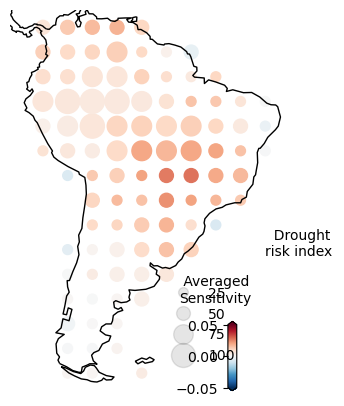

In [266]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import CenteredNorm,TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import xarray as xr
from matplotlib.colors import CenteredNorm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import xarray as xr
import numpy as np
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from get_lat_lon import get_lat_lon
from matplotlib.colors import CenteredNorm,TwoSlopeNorm,Normalize
import pickle
import datetime
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
fig = plt.figure(figsize=(5, 5))
gs = plt.GridSpec(1, 1,wspace=0.5, hspace=0)

subplot_kw=dict(projection=ccrs.PlateCarree())
ax0 = fig.add_subplot(gs[:, 0],**subplot_kw,)

ax0.coastlines() 
ax0.set_extent([-84, -30, -55, 11])
# gl = axis[0].gridlines(draw_labels=True, linewidth=0.2, color='white', alpha=0.5, linestyle='--')
# gl.top_labels=False                                 
# gl.right_labels=False
for spine in ax0.spines.values():
    spine.set_visible(False)
norm=TwoSlopeNorm(vmin=-0.05,vcenter=0., vmax=0.05)

boundary = np.array([0,25,50,75,100]) # 这里假设是示例边界 # 根据边界调整点的大小 
drought=ds.drought.values
sizes = np.piecewise(drought, [
                               (drought >= boundary[0])& (drought < boundary[1]), 
                               (drought >= boundary[1])& (drought < boundary[2]),
                               (drought >= boundary[2])& (drought < boundary[3]),
                               (drought >= boundary[3])& (drought < boundary[4]),
                               (drought >= boundary[4])], [50,100,200,300,400])

lon_grid=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought_3_lon_grid.npy",)
lat_grid=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought_3_lat_grid.npy")
sc=ax0.scatter(lon_grid ,lat_grid,s=sizes,norm=norm,c=-ds.eg, cmap='RdBu_r',marker="o")

handles,labels=sc.legend_elements(prop="sizes",alpha=0.1)
ax_cb=inset_axes(ax0, width="5%",height="30%",borderpad=0, bbox_to_anchor=(0.45, -0.2, 0.6, 0.6), 
                             bbox_transform=ax0.transAxes, loc='center')
cb1=fig.colorbar(sc, cax=ax_cb,fraction=0.01,pad=0.1,shrink=1,ticks=[-0.05,0,0.05],extend='both',ticklocation='left')  
custom_labels = ['25','50','75', '100'] # 添加图例，设置自定义位置和标签 
fig.legend(handles, custom_labels, loc='center', bbox_to_anchor=(0.6, 0.25),frameon=False)
ax0.text(0.57, 0.24, " Averaged\nSensitivity", transform=ax0.transAxes, fontsize=10)
ax0.text(0.86, 0.36, "  Drought \nrisk index", transform=ax0.transAxes, fontsize=10)

In [ ]:
====
9.1 直接用阈值计算干旱风险等级，不考虑干旱事件

In [78]:
import pandas as pd
eg_receive=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive.npy',)
percentile=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/sma_percentiles.npy")

mask=percentile > 0.1
percentile[mask] = np.nan
eg_receive[mask] = np.nan


frequency=np.sum(percentile < 0.1, axis=1)
risk_index=(1-np.nanmean(percentile,axis=1))*np.array(frequency)
risk_index=(risk_index-np.nanmin(risk_index))/(np.nanmax(risk_index)-np.nanmin(risk_index))*100

lats=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats.npy")
lons=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons.npy")
y=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:,:,-1]
nanindex=np.where(np.isnan(y[:,205]))
lats=np.delete(lats,nanindex,axis=0)
lons=np.delete(lons,nanindex,axis=0)


df=pd.DataFrame({"lat":lats,"lon":lons,"drought":risk_index,
                 "eg":np.nanmean(eg_receive[:,:,0],axis=1)})
ds1 = df.set_index(['lat', 'lon']).to_xarray()
ds=ds1.coarsen(lat=3,lon=3).mean()
ds['lon'] =ds['lon'].where(ds['lon'] != -9999)
ds['lat'] = ds['lat'].where(ds['lat'] != -9999)
lon_grid, lat_grid = np.meshgrid(ds['lon'].values, ds['lat'].values)
# np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought_3_lon_grid.npy",lon_grid)
# np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought_3_lat_grid.npy",lat_grid)
# ds.to_netcdf("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought_3.nc")

Text(0.86, 0.36, '  Drought \nrisk index')

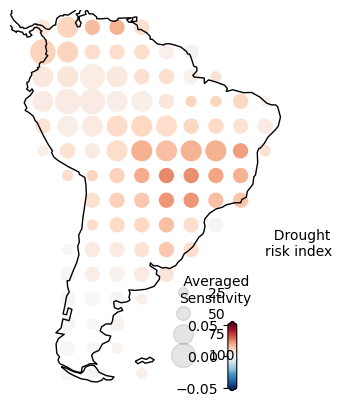

In [79]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import CenteredNorm,TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import xarray as xr
from matplotlib.colors import CenteredNorm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import xarray as xr
import numpy as np
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from get_lat_lon import get_lat_lon
from matplotlib.colors import CenteredNorm,TwoSlopeNorm,Normalize
import pickle
import datetime
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
fig = plt.figure(figsize=(5, 5))
gs = plt.GridSpec(1, 1,wspace=0.5, hspace=0)

subplot_kw=dict(projection=ccrs.PlateCarree())
ax0 = fig.add_subplot(gs[:, 0],**subplot_kw,)

ax0.coastlines() 
ax0.set_extent([-84, -30, -55, 11])
# gl = axis[0].gridlines(draw_labels=True, linewidth=0.2, color='white', alpha=0.5, linestyle='--')
# gl.top_labels=False                                 
# gl.right_labels=False
for spine in ax0.spines.values():
    spine.set_visible(False)
norm=TwoSlopeNorm(vmin=-0.05,vcenter=0., vmax=0.05)

boundary = np.array([0,25,50,75,100]) # 这里假设是示例边界 # 根据边界调整点的大小 
drought=ds.drought.values
sizes = np.piecewise(drought, [
                               (drought >= boundary[0])& (drought < boundary[1]), 
                               (drought >= boundary[1])& (drought < boundary[2]),
                               (drought >= boundary[2])& (drought < boundary[3]),
                               (drought >= boundary[3])& (drought < boundary[4]),
                               (drought >= boundary[4])], [50,100,200,300,400])

# lon_grid=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought_3_lon_grid.npy",)
# lat_grid=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought_3_lat_grid.npy")
sc=ax0.scatter(lon_grid ,lat_grid,s=sizes,norm=norm,c=-ds.eg, cmap='RdBu_r',marker="o")

handles,labels=sc.legend_elements(prop="sizes",alpha=0.1)
ax_cb=inset_axes(ax0, width="5%",height="30%",borderpad=0, bbox_to_anchor=(0.45, -0.2, 0.6, 0.6), 
                             bbox_transform=ax0.transAxes, loc='center')
cb1=fig.colorbar(sc, cax=ax_cb,fraction=0.01,pad=0.1,shrink=1,ticks=[-0.05,0,0.05],extend='both',ticklocation='left')  
custom_labels = ['25','50','75', '100'] # 添加图例，设置自定义位置和标签 
fig.legend(handles, custom_labels, loc='center', bbox_to_anchor=(0.6, 0.25),frameon=False)
ax0.text(0.57, 0.24, " Averaged\nSensitivity", transform=ax0.transAxes, fontsize=10)
ax0.text(0.86, 0.36, "  Drought \nrisk index", transform=ax0.transAxes, fontsize=10)

In [ ]:
=================================================
10.统计干旱事件

In [6]:
import pandas as pd
import numpy as np
eg_recieve_drought=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought.npy',)
eg_receive=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive.npy')
risk_index=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_risk_index.npy")
drought_index=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_index_np_all.npy")
drought_extent=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_percentiles.npy")
merged_results_df=pd.read_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_tracking.csv")
drought_new_info=pd.read_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_info.csv")
percentile=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/sma_percentiles.npy")


ysomo=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:,:,-1]
nanindex=np.where(np.isnan(ysomo[:,205]))
y=np.squeeze(np.load('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/input_data/deseason_detrend/esa_sa_filled.npy'))
sma=np.delete(y,nanindex,axis=0)
area=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/890/eg_res/area_np.npy") 
area=np.delete(area,nanindex,axis=0)
area= np.tile(area, (216, 1)).T

In [10]:
import warnings
warnings.filterwarnings('ignore')
df=pd.DataFrame()

for i in range(len(merged_results_df)):  
    indexes=np.unique(merged_results_df.iloc[i,1:])[:-1]
    
    area_list=np.array([])
    month_list=np.array([])
    centroid_lat_list=np.array([])
    centroid_lon_list=np.array([])
    egs_list=np.array([])
    sma_list=np.array([])
    percentile_list=np.array([])

    area_list1=np.array([]);total_area_list1=np.array([])
    month_list1=np.array([])
    centroid_lat_list1=np.array([])
    centroid_lon_list1=np.array([])
    egs_list1=np.array([])
    sma_list1=np.array([])
    percentile_list1=np.array([])
    for j in range(len(indexes)):
        index=indexes[j]        
        mask = (drought_index == index)
        
        pecentile_mean = np.nanmean(percentile[mask])
        sma_mean=np.nanmean(sma[mask])
        eg_receive_mean=np.nanmean(eg_receive[mask])
        area_mean_m_list=[]
        for mi in np.unique(np.where(mask==True)[1]):
            area_mean_m_list.append(np.nansum(area[mask[:,mi]]))
        area_mean= np.array(area_mean_m_list)/len(np.unique(np.where(mask==True)[1])) 
        area_sum=np.nansum(area[mask])
        
        
        percentile_list1=np.append(percentile_list1,pecentile_mean)
        egs_list1=np.append(egs_list1,eg_receive_mean)
        sma_list1=np.append(sma_list1,sma_mean)
        month_list1=np.append(month_list1,np.unique(np.where(mask==True)[1]))
        area_list1=np.append(area_list1,area_mean)
        total_area_list1=np.append(total_area_list1,area_sum)
        row_info=drought_new_info[drought_new_info['old_index']==index]
        centroid_lat_list=np.append(centroid_lat_list,row_info['centroid_lat'].values)
        centroid_lon_list=np.append(centroid_lon_list,row_info['centroid_lon'].values)
     
    
    df.loc[i,"index"]=i   
    df.loc[i,"mean_area"]=np.nanmean(area_list1) 
    df.loc[i,"total_area"]=np.nansum(area_list1) 
    df.loc[i,"mean_month"]=np.nanmean(month_list1) 
    df.loc[i,"months"]=len(np.unique(month_list1))
    df.loc[i,"centroid_lat"]=np.nanmean(centroid_lat_list)
    df.loc[i,"centroid_lon"]=np.nanmean(centroid_lon_list)
    df.loc[i,"egs"]=np.nanmean(np.array(egs_list1))
    df.loc[i,"sma"]=np.nanmean(np.array(sma_list1))
    df.loc[i,"percentile"]=np.nanmean(np.array(percentile_list1))


df.to_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_statistics.csv")    

0 [    0. 10848. 10891.    nan]
[10848. 10891.]
1 [1.0000e+00 1.0889e+04 1.0925e+04 1.0926e+04 1.0986e+04 1.1010e+04
        nan]
[10889. 10925. 10926. 10986. 11010.]
2 [2.0000e+00 1.0914e+04 1.0967e+04 1.1012e+04        nan]
[10914. 10967. 11012.]
3 [3.0000e+00 1.0956e+04 1.1019e+04 1.1079e+04 1.1124e+04        nan]
[10956. 11019. 11079. 11124.]
4 [4.0000e+00 1.1293e+04 1.1344e+04        nan]
[11293. 11344.]
5 [5.0000e+00 1.1369e+04 1.1419e+04        nan]
[11369. 11419.]
6 [6.0000e+00 1.1386e+04 1.1439e+04 1.1496e+04        nan]
[11386. 11439. 11496.]
7 [7.0000e+00 1.1420e+04 1.1482e+04 1.1550e+04        nan]
[11420. 11482. 11550.]
8 [8.0000e+00 1.1421e+04 1.1483e+04        nan]
[11421. 11483.]
9 [9.0000e+00 1.1422e+04 1.1484e+04        nan]
[11422. 11484.]
10 [1.0000e+01 1.1562e+04 1.1629e+04 1.1698e+04 1.1746e+04        nan]
[11562. 11629. 11698. 11746.]
11 [1.1000e+01 1.1616e+04 1.1676e+04        nan]
[11616. 11676.]
12 [   12. 11650. 11744.    nan]
[11650. 11744.]
13 [   13. 11728

In [73]:
ymin=np.nanmin(sma)
ymax=np.nanmax(sma)

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df.sma,-df.egs*(ymax-ymin),df.total_area/5000000,df.months)
plt.legend()
plt.colorbar()

In [ ]:
====================================================================
11.找最大/最长的干旱事件

In [1]:
import numpy as np
import pandas as pd
drought_index=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_index_np_all.npy")
# eg_recieve_drought=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive_drought.npy',)
eg_receive=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/eg_receive.npy')

df=pd.read_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_statistics.csv")
merged_results_df=pd.read_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/drought_new_tracking.csv")

In [11]:
mask = (drought_index == 16388)
np.where(mask==True)

(array([124, 146, 147, 148, 172, 173, 174, 175, 200, 201, 202, 203, 204,
        231, 232, 233, 261, 262]),
 array([116, 116, 116, 116, 116, 116, 116, 116, 116, 116, 116, 116, 116,
        116, 116, 116, 116, 116]))

In [5]:
long_index=df[df['months']==df['months'].max()].index.values[0]
indexes=np.unique(merged_results_df.iloc[long_index,1:])[:-1]
for j in range(len(indexes)):
        index=indexes[j]        
        mask = (drought_index == index)
        
        pecentile_mean = np.nanmean(percentile[mask])
        sma_mean=np.nanmean(sma[mask])
        eg_receive_mean=np.nanmean(eg_receive[mask])
        area_mean_m_list=[]
        for mi in np.unique(np.where(mask==True)[1]):
            area_mean_m_list.append(np.nansum(area[mask[:,mi]]))
        area_mean= np.array(area_mean_m_list)/len(np.unique(np.where(mask==True)[1])) 
        area_sum=np.nansum(area[mask])

Unnamed: 0       59.0
0             16388.0
1             16134.0
2             16264.0
3             16394.0
4             16013.0
5             16525.0
6             15899.0
7             16425.0
8             16298.0
9             15915.0
10            15919.0
11            16433.0
12            16050.0
13            16183.0
14            15803.0
15            16472.0
16            16347.0
17            16091.0
18            16093.0
19            16223.0
20            15974.0
21            16367.0
22            15991.0
23            15864.0
24            16124.0
25                NaN
Name: 59, dtype: float64